In [ ]:
import numpy as np

In [5]:

data = np.load("output/latents/defect/data.npz", allow_pickle=True)

mus = data['mu']
labels = data['labels']
logvars = data['logvar']


In [6]:

mus.shape, labels.shape, logvars.shape, mus.dtype, labels.dtype, logvars.dtype

((128, 1, 256, 14, 14),
 (128,),
 (128, 1, 256, 14, 14),
 dtype('float32'),
 dtype('int32'),
 dtype('float32'))

In [14]:
array_squeezed = np.squeeze(mus, axis=1)
# Step 2: Select or manipulate to get (128, 14, 14)
# Assuming you want to discard the 256 dimension by taking one slice or reducing it
# Here, I'll take the first slice of the 256 dimension as an example
array_reduced = array_squeezed[:, 0, :, :]  # Shape: (128, 14, 14)
# Step 3: Flatten the last two dimensions (14*14=196) to get (128, 196)
mus_flattened = array_reduced.reshape(128, -1)
mus_flattened.shape, mus_flattened.dtype

((128, 196), dtype('float32'))

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
mus_pca = pca.fit_transform(mus_flattened)

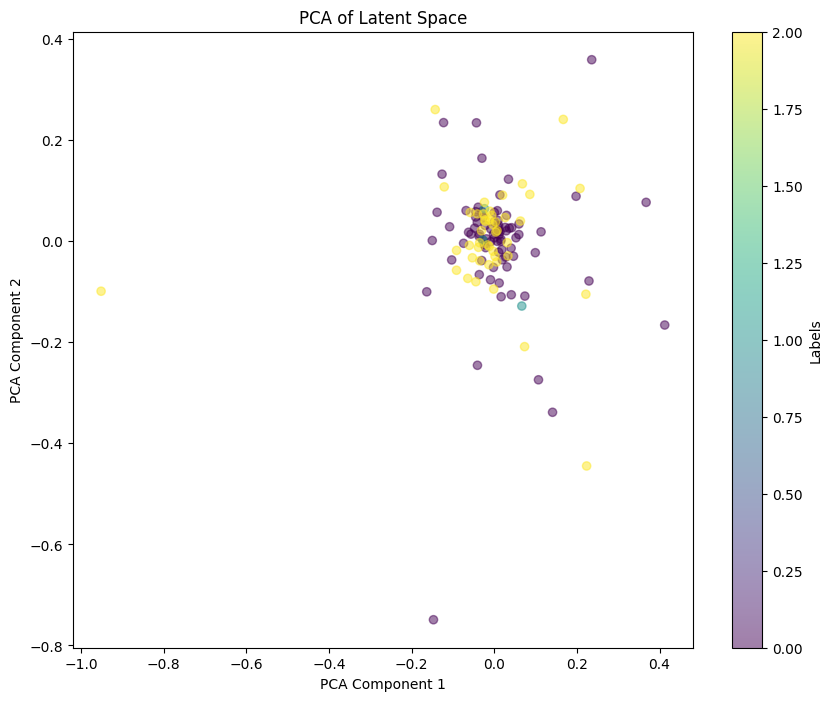

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(mus_pca[:, 0], mus_pca[:, 1], c=labels, cmap='viridis', alpha=0.5)
plt.colorbar(label='Labels')
plt.title('PCA of Latent Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

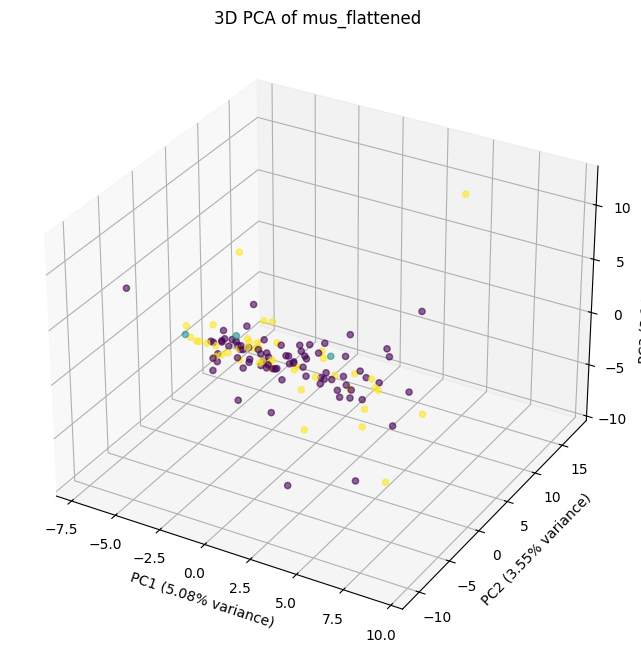

Explained variance ratios: [0.05079278 0.03549572 0.03143597]
Total explained variance: 0.1177244707942009


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming mus_flattened is your input data (n_samples, n_features)
# If not already defined, you might need to load or create it
# Example: mus_flattened = np.random.rand(100, 50)  # Uncomment for testing

# Standardize the data
scaler = StandardScaler()
mus_scaled = scaler.fit_transform(mus_flattened)

# Apply PCA to reduce to 3 components
pca = PCA(n_components=3)
mus_pca = pca.fit_transform(mus_scaled)

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the 3D PCA results
scatter = ax.scatter(mus_pca[:, 0], mus_pca[:, 1], mus_pca[:, 2], c=labels, alpha=0.6)

# Set labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('3D PCA of mus_flattened')

# Optional: Add grid
ax.grid(True)

# Show plot
plt.show()

# Print explained variance ratios
print("Explained variance ratios:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))